# Unsupervised Discovery: Smartwatch Activity Clustering## K-Means, DBSCAN & PCA — Finding Structure Without Labels**Project:** 006 — The AI Engineering Lab  **Objective:** Discover hidden activity clusters in smartwatch sensor data.  **Advanced Concepts:** K-Means++ initialization, Elbow vs Silhouette vs Davies-Bouldin, DBSCAN ε-selection via k-distance plot, PCA, ARI.

---## 1. Setup and Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, adjusted_rand_score, davies_bouldin_score
from sklearn.neighbors import NearestNeighbors

COLORS = {'primary': '#0D47A1', 'secondary': '#FF6F00', 'accent': '#2E7D32', 'highlight': '#C62828'}
plt.rcParams.update({'figure.dpi': 120, 'font.size': 10, 'axes.titlesize': 12})
print('Libraries loaded.')

Libraries loaded.


---## 2. Load and Explore4,000 smartwatch readings. We drop `true_activity` — the point is to discover structure without it.

In [2]:
df = pd.read_csv('../data/smartwatch_activity.csv')
print(f'Shape: {df.shape}')
print(f'Activities (hidden): {df["true_activity"].unique().tolist()}')
df.head()

Shape: (4000, 7)
Activities (hidden): ['Running', 'Gym', 'Desk Work', 'Cycling', 'Walking', 'Sleeping']


,steps_per_min,heart_rate_bpm,accelerometer_magnitude,skin_temperature_c,calories_per_min,gyroscope_magnitude,true_activity
0,155.394,156.659,4.114,36.144,9.964,2.374,Running
1,75.724,129.537,3.840,37.169,16.141,3.835,Gym
2,161.972,153.523,3.535,37.241,12.554,1.838,Running
3,46.194,143.121,3.799,37.083,18.151,2.687,Gym
4,5.525,71.120,0.379,36.378,1.528,0.190,Desk Work


In [3]:
y_true = df['true_activity']
X = df.drop(columns=['true_activity'])
feature_names = X.columns.tolist()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print(f'Features ({len(feature_names)}): {feature_names}')

Features (6): ['steps_per_min', 'heart_rate_bpm', 'accelerometer_magnitude', 'skin_temperature_c', 'calories_per_min', 'gyroscope_magnitude']


---## 3. Exploratory Data Analysis

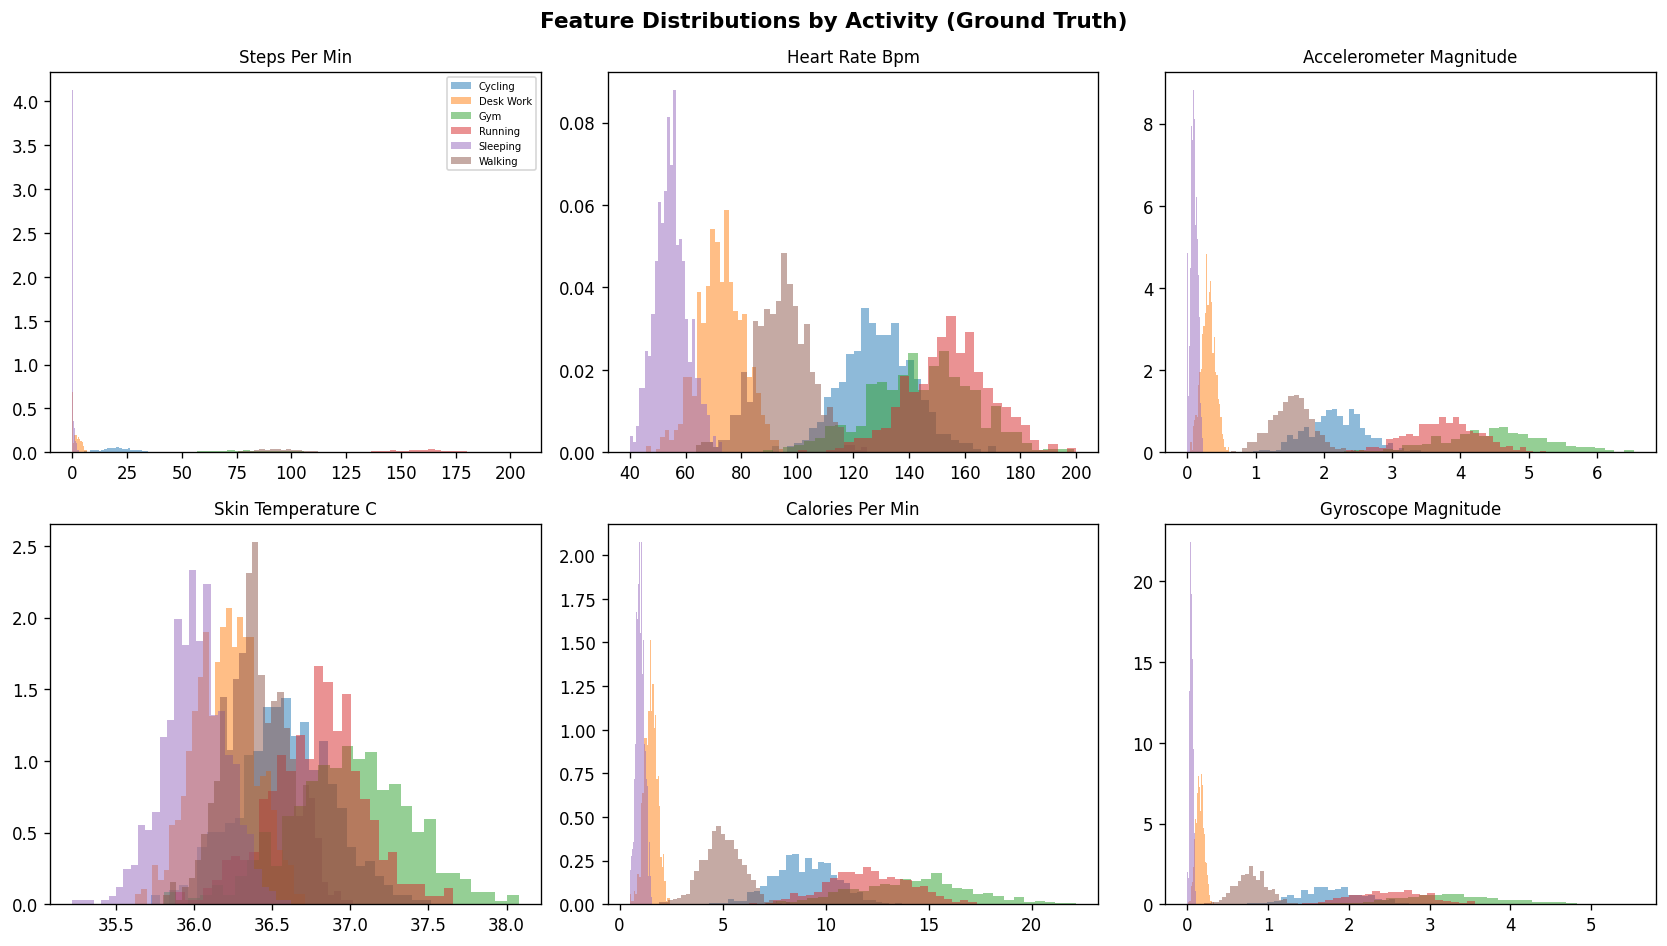

In [4]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
for i, col in enumerate(feature_names):
    ax = axes[i // 3, i % 3]
    for act in sorted(y_true.unique()):
        subset = df[y_true == act][col]
        ax.hist(subset, bins=30, alpha=0.5, label=act, density=True)
    ax.set_title(col.replace('_', ' ').title(), fontsize=10)
    if i == 0:
        ax.legend(fontsize=6)
plt.suptitle('Feature Distributions by Activity (Ground Truth)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../assets/eda_smartwatch.png', dpi=150, bbox_inches='tight')
plt.show()

---## 4. PCA — Dimensionality Reduction

Explained variance: PC1=0.810, PC2=0.083


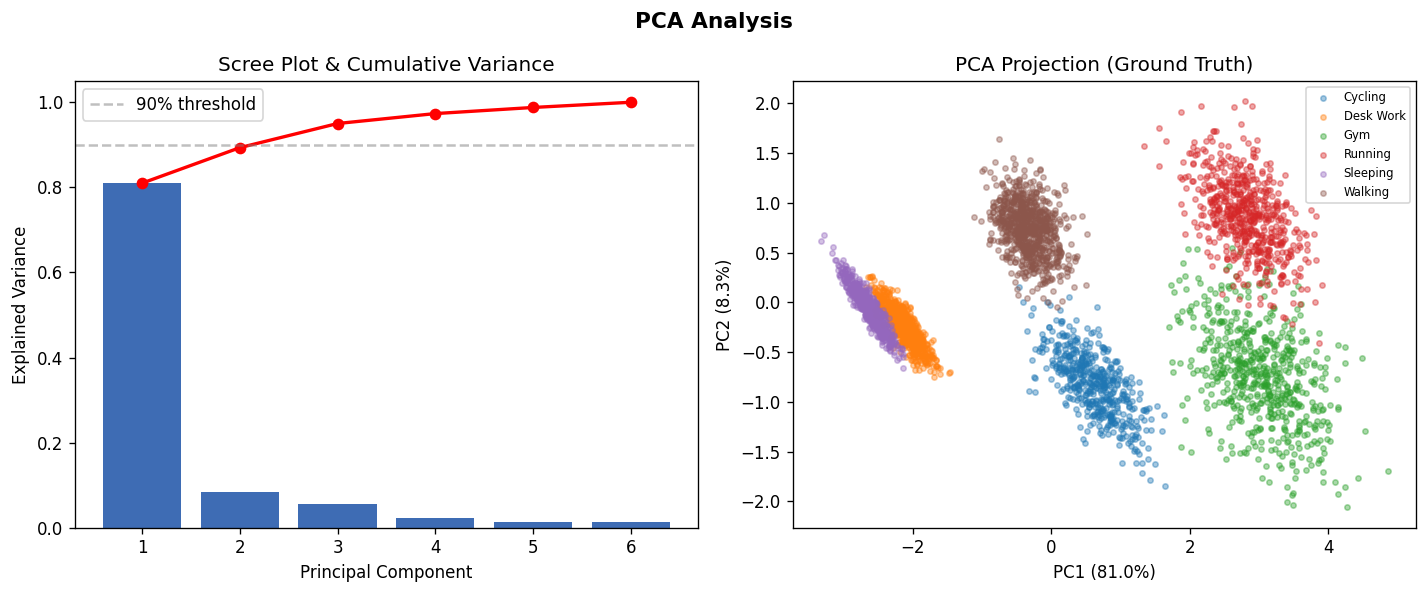

In [5]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
print(f'Explained variance: PC1={pca.explained_variance_ratio_[0]:.3f}, PC2={pca.explained_variance_ratio_[1]:.3f}')

pca_full = PCA().fit(X_scaled)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].bar(range(1, len(pca_full.explained_variance_ratio_)+1),
            pca_full.explained_variance_ratio_, color=COLORS['primary'], alpha=0.8)
axes[0].plot(range(1, len(pca_full.explained_variance_ratio_)+1),
             np.cumsum(pca_full.explained_variance_ratio_), 'ro-', linewidth=2)
axes[0].axhline(0.9, color='gray', linestyle='--', alpha=0.5, label='90% threshold')
axes[0].set_xlabel('Principal Component'); axes[0].set_ylabel('Explained Variance')
axes[0].set_title('Scree Plot & Cumulative Variance'); axes[0].legend()

for act in sorted(y_true.unique()):
    mask = y_true == act
    axes[1].scatter(X_pca[mask, 0], X_pca[mask, 1], alpha=0.4, s=10, label=act)
axes[1].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
axes[1].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
axes[1].set_title('PCA Projection (Ground Truth)'); axes[1].legend(fontsize=7)
plt.suptitle('PCA Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../assets/pca_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

---## 5. K-Means Clustering — Choosing K

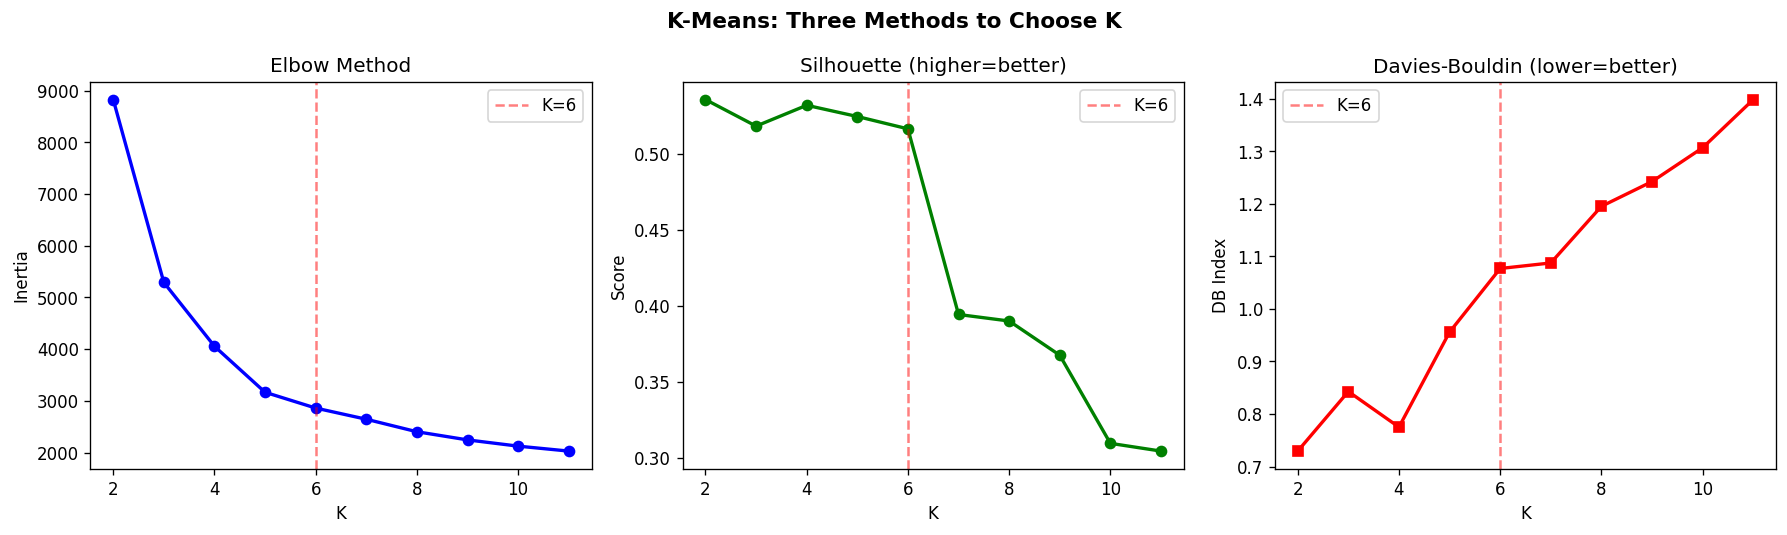

In [6]:
K_range = range(2, 12)
inertias, silhouettes, db_scores = [], [], []
for k in K_range:
    km = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels))
    db_scores.append(davies_bouldin_score(X_scaled, labels))

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
axes[0].plot(K_range, inertias, 'bo-', linewidth=2, markersize=6)
axes[0].axvline(6, color='red', linestyle='--', alpha=0.5, label='K=6')
axes[0].set_title('Elbow Method'); axes[0].set_xlabel('K'); axes[0].set_ylabel('Inertia'); axes[0].legend()
axes[1].plot(K_range, silhouettes, 'go-', linewidth=2, markersize=6)
axes[1].axvline(6, color='red', linestyle='--', alpha=0.5, label='K=6')
axes[1].set_title('Silhouette (higher=better)'); axes[1].set_xlabel('K'); axes[1].set_ylabel('Score'); axes[1].legend()
axes[2].plot(K_range, db_scores, 'rs-', linewidth=2, markersize=6)
axes[2].axvline(6, color='red', linestyle='--', alpha=0.5, label='K=6')
axes[2].set_title('Davies-Bouldin (lower=better)'); axes[2].set_xlabel('K'); axes[2].set_ylabel('DB Index'); axes[2].legend()
plt.suptitle('K-Means: Three Methods to Choose K', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../assets/kmeans_k_selection.png', dpi=150, bbox_inches='tight')
plt.show()

In [7]:
km_final = KMeans(n_clusters=6, init='k-means++', n_init=10, random_state=42)
km_labels = km_final.fit_predict(X_scaled)
print(f'K-Means (K=6):')
print(f'  Silhouette: {silhouette_score(X_scaled, km_labels):.3f}')
print(f'  ARI vs ground truth: {adjusted_rand_score(y_true, km_labels):.3f}')
print(f'  Cluster sizes: {np.bincount(km_labels).tolist()}')

K-Means (K=6):
  Silhouette: 0.516
  ARI vs ground truth: 0.739
  Cluster sizes: [1500, 595, 800, 501, 269, 335]


---## 6. DBSCAN — Density-Based Clustering

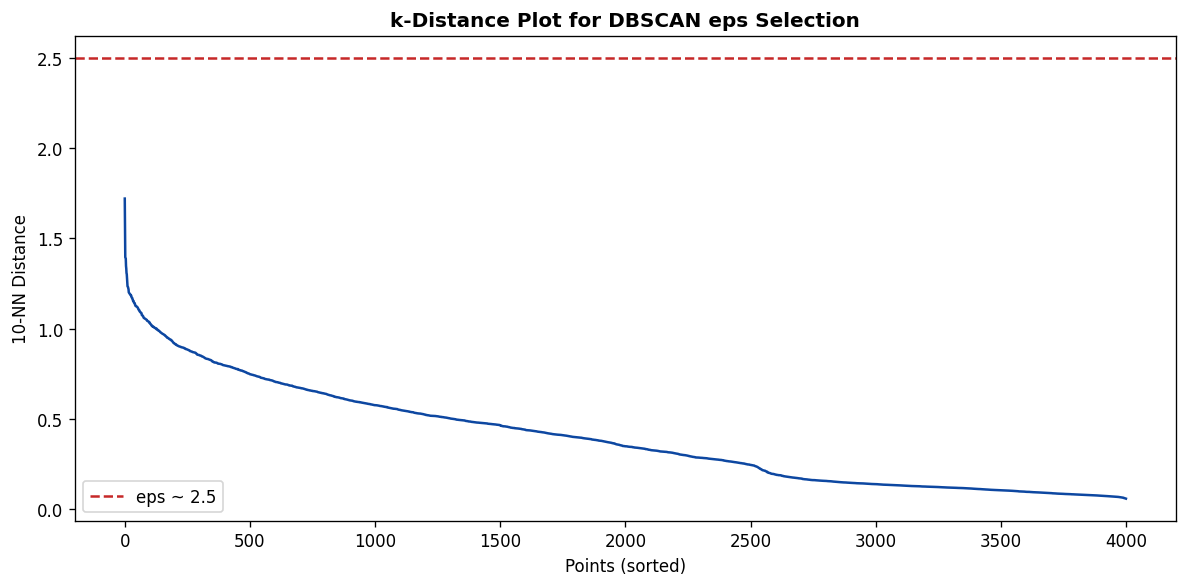

DBSCAN: 1 clusters, 0 noise pts (0.0%)


In [8]:
nn = NearestNeighbors(n_neighbors=10).fit(X_scaled)
distances, _ = nn.kneighbors(X_scaled)
k_dist = np.sort(distances[:, -1])[::-1]

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(k_dist, color=COLORS['primary'], linewidth=1.5)
ax.axhline(y=2.5, color=COLORS['highlight'], linestyle='--', label='eps ~ 2.5')
ax.set_xlabel('Points (sorted)'); ax.set_ylabel('10-NN Distance')
ax.set_title('k-Distance Plot for DBSCAN eps Selection', fontsize=12, fontweight='bold')
ax.legend(); plt.tight_layout(); plt.show()

db = DBSCAN(eps=2.5, min_samples=10)
db_labels = db.fit_predict(X_scaled)
n_clusters_db = len(set(db_labels)) - (1 if -1 in db_labels else 0)
n_noise = (db_labels == -1).sum()
print(f'DBSCAN: {n_clusters_db} clusters, {n_noise} noise pts ({n_noise/len(db_labels)*100:.1f}%)')
if n_clusters_db > 1:
    mask = db_labels != -1
    print(f'  Silhouette (excl noise): {silhouette_score(X_scaled[mask], db_labels[mask]):.3f}')
    print(f'  ARI: {adjusted_rand_score(y_true, db_labels):.3f}')

---## 7. Visual Comparison

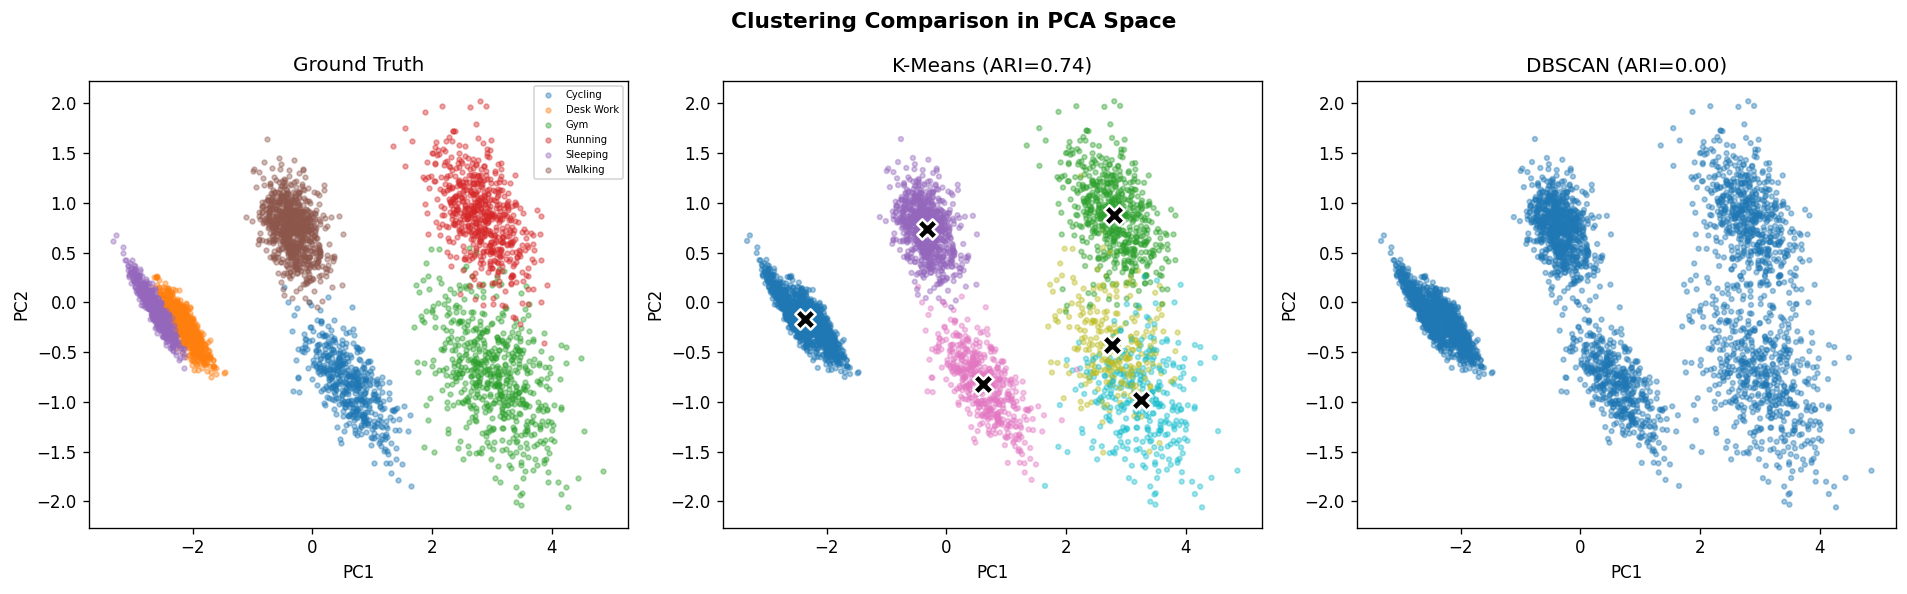

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for act in sorted(y_true.unique()):
    mask = y_true == act
    axes[0].scatter(X_pca[mask, 0], X_pca[mask, 1], alpha=0.4, s=8, label=act)
axes[0].set_title('Ground Truth'); axes[0].legend(fontsize=6)

axes[1].scatter(X_pca[:, 0], X_pca[:, 1], c=km_labels, cmap='tab10', alpha=0.4, s=8)
centroids_pca = pca.transform(km_final.cluster_centers_)
axes[1].scatter(centroids_pca[:, 0], centroids_pca[:, 1], c='black', marker='X', s=150, edgecolors='white', linewidths=1.5)
axes[1].set_title(f'K-Means (ARI={adjusted_rand_score(y_true, km_labels):.2f})')

axes[2].scatter(X_pca[:, 0], X_pca[:, 1], c=db_labels, cmap='tab10', alpha=0.4, s=8)
axes[2].set_title(f'DBSCAN (ARI={adjusted_rand_score(y_true, db_labels):.2f})')

for ax in axes:
    ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
plt.suptitle('Clustering Comparison in PCA Space', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../assets/clustering_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

---## 8. Summary

In [10]:
results = pd.DataFrame({
    'Method': ['K-Means (K=6)', 'DBSCAN (eps=2.5)'],
    'Clusters': [6, n_clusters_db],
    'ARI': [round(adjusted_rand_score(y_true, km_labels), 3), round(adjusted_rand_score(y_true, db_labels), 3)],
    'Noise': [0, n_noise]
})
print(results.to_string(index=False))
print('\nNotebook complete.')

          Method  Clusters   ARI  Noise
   K-Means (K=6)         6 0.739      0
DBSCAN (eps=2.5)         1 0.000      0

Notebook complete.
